In [1]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt

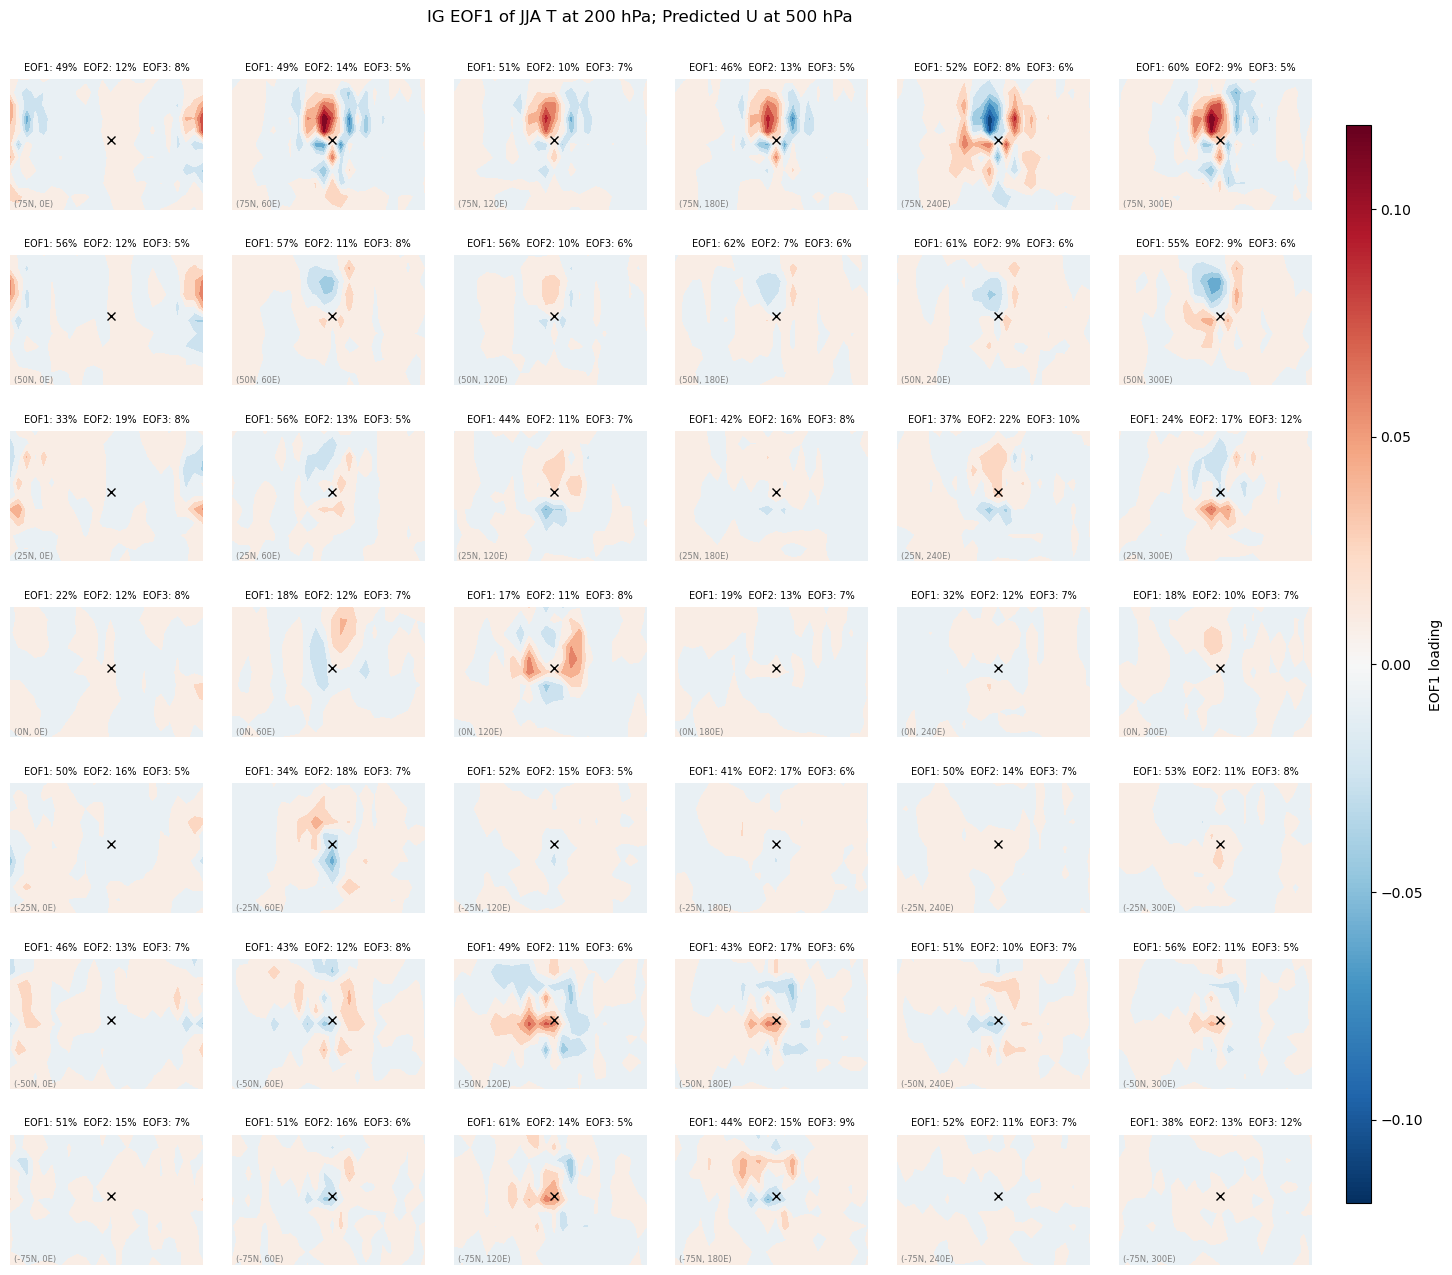

In [19]:
# ============================================================
# CONFIG
# ============================================================
save_ddir = '/glade/derecho/scratch/kjmayer/CUVACAR_xai/IG/EOF_analysis/predictU/'
eofval_name = "T"      # U, V, or T -- variable of EOF
eof_sel = 0            # options: 0, 1, 2
eof_lev = 200          # level of EOF in hPa
lev_of_interest = 500  # options: 200, 500, 850 -- level of U in hPa

season = "JJA"               # or "DJF" -- change to switch which file set is used

# ============================================================
# GRID DEFINITION (from your original loop)
# ============================================================
lats_of_interest = [-75, -50, -25, 0, 25, 50, 75]   # N
lons_of_interest = [0, 60, 120, 180, 240, 300]       # E

# geographic ordering: north at top, west-to-east left to right
lat_plot_order = sorted(lats_of_interest, reverse=True)
lon_plot_order = sorted(lons_of_interest)

nrows, ncols = len(lat_plot_order), len(lon_plot_order)

# ============================================================
# open all files, extract EOF1@internal_lev, compute shared color scale
# ============================================================
data_grid = {}   # (lat_of_interest, lon_of_interest) -> (eof1_spatial_2d, eigenvalue_pct_list)
global_vmax = 0

for lat_of_interest in lats_of_interest:
    for lon_of_interest in lons_of_interest:
        finame = f"EOF1-3_{season}_{eofval_name}_{lat_of_interest}x{lon_of_interest}_{lev_of_interest}hPa.nc"
        ds = xr.open_dataset(save_ddir + finame)

        # slice this file's own internal vertical structure at internal_lev_hPa
        eof1_2d = ds["eof_map"].sel(lev=eof_lev, method="nearest").isel(eof=eof_sel)
        # ^ ASSUMES the EOF field variable is named "EOF" with dims (lev, lat, lon, eof) -- verify against your file

        eigvals = ds["eigenvalues"].values  # ASSUMES shape (3,) -- one value per EOF mode
        eigval_pct = 100 * eigvals

        data_grid[(lat_of_interest, lon_of_interest)] = (eof1_2d, eigval_pct)
        global_vmax = max(global_vmax, np.abs(eof1_2d.values).max())

        ds.close()

# ============================================================
# build the geographically-arranged figure
# ============================================================
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.8, nrows * 2.2), squeeze=False)

for row, lat_of_interest in enumerate(lat_plot_order):
    for col, lon_of_interest in enumerate(lon_plot_order):
        ax = axes[row, col]
        eof1_2d, eigval_pct = data_grid[(lat_of_interest, lon_of_interest)]

        im = ax.contourf(
            eof1_2d.lon, eof1_2d.lat, eof1_2d.values,
            levels=np.linspace(-global_vmax, global_vmax, 15),
            cmap="RdBu_r", extend="both"
        )
        # mark the actual (lat_of_interest, lon_of_interest) location within this subplot's own domain
        ax.plot(lon_of_interest, lat_of_interest, "x",
                 color="black", markersize=6)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_title(
            f"EOF1: {eigval_pct[0]:.0f}%  EOF2: {eigval_pct[1]:.0f}%  EOF3: {eigval_pct[2]:.0f}%",
            fontsize=7
        )

        # geographic reference label
        ax.text(0.02, 0.02, f"({lat_of_interest}N, {lon_of_interest}E)",
                 transform=ax.transAxes, fontsize=6, color="gray")

fig.suptitle(
    f"IG EOF1 of {season} {eofval_name} at {eof_lev} hPa; "
    f"Predicted U at {lev_of_interest} hPa",
    fontsize=12, y=0.925
)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=-global_vmax, vmax=global_vmax))
fig.colorbar(sm, cax=cbar_ax, label="EOF1 loading")

plt.subplots_adjust(wspace=0.15, hspace=0.35)
# plt.savefig(f"eof1_grid_{eofval_name}{eof_lev}hPa_{season}_U{lev_of_interest}hPa.png", dpi=200, bbox_inches="tight")
plt.show()